LAB 9: Distributed Inference with Generators
make_blobs shape: (60, 6)
make_classification shape: (60, 6)

Decision Distribution
Edge decisions: 18 (100.0%)
Cloud decisions: 0 (0.0%)

Accuracy
Hybrid Accuracy: 100.0
Edge Only Accuracy: 100.0
Cloud Only Accuracy: 100.0

Clustering Quality (ARI): 1.0


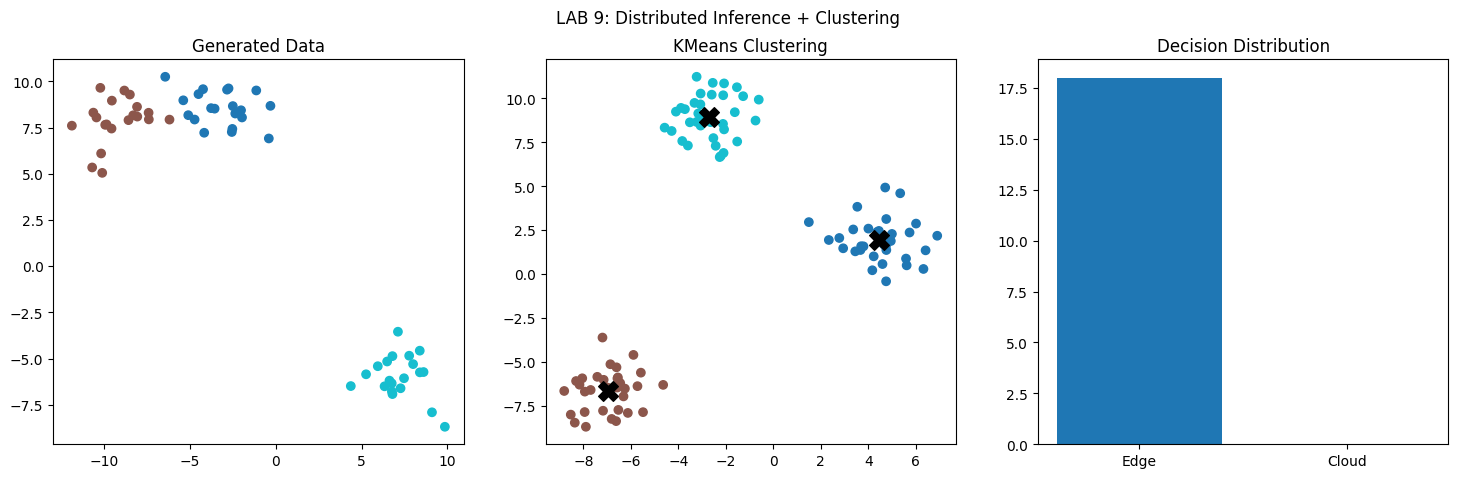

In [1]:
#==========================================================
# LAB 9 - Distributed Inference Pipeline with Generators
# Run on: Google Colab / Python 3.x
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, adjusted_rand_score
from sklearn.ensemble import RandomForestClassifier

print("="*60)
print("LAB 9: Distributed Inference with Generators")
print("="*60)

# ==========================================================
# STEP 1: Generate Data
# ==========================================================

X_blob, y_blob = make_blobs(
    n_samples=60,
    centers=3,
    cluster_std=1.5,
    n_features=6,
    random_state=42
)

X_cls, y_cls = make_classification(
    n_samples=60,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_classes=3,
    random_state=42
)

print("make_blobs shape:", X_blob.shape)
print("make_classification shape:", X_cls.shape)

# ==========================================================
# STEP 2: Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_blob,
    y_blob,
    test_size=0.3,
    random_state=42
)

# ==========================================================
# STEP 3: Edge Model (Lightweight Model)
# ==========================================================

edge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3)),
    ('clf', LogisticRegression(max_iter=1000))
])

edge_pipe.fit(X_train, y_train)

# ==========================================================
# STEP 4: Cloud Model (Heavy Model)
# ==========================================================

cloud_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100))
])

cloud_pipe.fit(X_train, y_train)

# ==========================================================
# STEP 5: Distributed Inference
# ==========================================================

THRESHOLD = 0.80
edge_count = 0
cloud_count = 0
final_preds = []

for i in range(len(X_test)):

    x = X_test[i].reshape(1,-1)

    proba = edge_pipe.predict_proba(x)[0]
    confidence = np.max(proba)

    if confidence >= THRESHOLD:
        final_preds.append(np.argmax(proba))
        edge_count += 1
    else:
        final_preds.append(cloud_pipe.predict(x)[0])
        cloud_count += 1

total = len(X_test)

# ==========================================================
# STEP 6: Accuracy Comparison
# ==========================================================

hybrid_acc = accuracy_score(y_test, final_preds)

edge_preds = edge_pipe.predict(X_test)
cloud_preds = cloud_pipe.predict(X_test)

edge_acc = accuracy_score(y_test, edge_preds)
cloud_acc = accuracy_score(y_test, cloud_preds)

print("\nDecision Distribution")
print("Edge decisions:", edge_count, f"({edge_count/total*100:.1f}%)")
print("Cloud decisions:", cloud_count, f"({cloud_count/total*100:.1f}%)")

print("\nAccuracy")
print("Hybrid Accuracy:", hybrid_acc*100)
print("Edge Only Accuracy:", edge_acc*100)
print("Cloud Only Accuracy:", cloud_acc*100)

# ==========================================================
# STEP 7: KMeans Clustering
# ==========================================================

X_clust, y_clust = make_blobs(
    n_samples=100,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

kmeans = KMeans(n_clusters=3, n_init=10)
labels = kmeans.fit_predict(X_clust)

ari = adjusted_rand_score(y_clust, labels)

print("\nClustering Quality (ARI):", ari)

# ==========================================================
# STEP 8: Visualization
# ==========================================================

fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle("LAB 9: Distributed Inference + Clustering")

# Generated Data
axes[0].scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap='tab10')
axes[0].set_title("Generated Data")

# KMeans
axes[1].scatter(X_clust[:,0], X_clust[:,1], c=labels, cmap='tab10')
centers = kmeans.cluster_centers_
axes[1].scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200)
axes[1].set_title("KMeans Clustering")

# Decision Distribution
axes[2].bar(['Edge','Cloud'], [edge_count, cloud_count])
axes[2].set_title("Decision Distribution")

plt.show()


In [2]:
# ==========================================================
# POST LAB: Algorithm Comparison
# ==========================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    random_state=42
)

algorithms = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

print("\nAlgorithm Comparison")
print("Algorithm\t\tAccuracy")

for name, model in algorithms.items():

    scores = cross_val_score(model, X, y, cv=5)
    print(name,"\t",round(scores.mean(),3))


Algorithm Comparison
Algorithm		Accuracy
Logistic Regression 	 0.856
Decision Tree 	 0.855
Random Forest 	 0.904
Gradient Boosting 	 0.9
SVM 	 0.861
KNN 	 0.847
Naive Bayes 	 0.839
